# Below-isotropic threshold

Produces Figure 7.

In [1]:
import sys
sys.path.insert(0, "..")   # make src importable from the repository root

from src.utils import load_results

results = load_results("below_isotropic_threshold")
p = results["params"]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from src import theory
from src.figstyle import (CMAPS, DASHES, MARKERS, PALETTE, PT, figure,
                          panel_label, param_colors, save_figure,
                          use_manuscript_style)
from src.analysis import detection_threshold, mean_crossing, threshold_from_levels

use_manuscript_style()
ALPHA_X, ALPHA_Y, RHO_Y = p['alpha_x'], p['alpha_y'], p['rho_y']
LEVELS = (0.05, 0.10, 0.15)   # recovery levels averaged in the crossing statistic
raw = results["threshold_sweeps"]
RHO_X_LIST = sorted({entry["rho_x"] for entry in raw.values()})
SAMPLE_SIZES = sorted({entry["N"] for entry in raw.values()})
data = {}
for rho_x in RHO_X_LIST:
    sweeps = {N: raw[f"rx{int(round(rho_x * 100)):03d}_N{N}"] for N in SAMPLE_SIZES}
    data[rho_x] = {"theta": sweeps[SAMPLE_SIZES[0]]["theta"], "sweeps": sweeps}

summary = {}
for rho_x in RHO_X_LIST:
    grid = data[rho_x]["theta"]
    summary[rho_x] = {
        N: threshold_from_levels(grid, sweep["Rx2"], LEVELS)
        for N, sweep in data[rho_x]["sweeps"].items()
    }


Wrote figures/fig7_below_isotropic_threshold.pdf


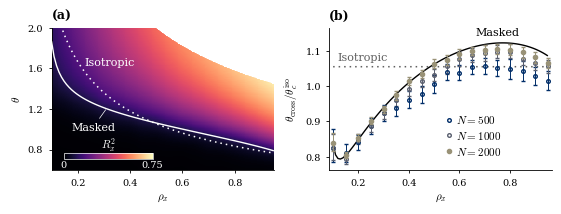

18 retentions, 3 sample sizes; isotropic crossing is a fixed 1.0549 x theta_c_iso
 rho_x  measured   masked  isotropic  R2 at edge  swept to


  0.10     1.877    1.868      2.359       0.118      4.47


  0.25     1.275    1.268      1.492       0.094      2.83


  0.40     1.133    1.129      1.179       0.094      2.24


  0.55     1.024    1.032      1.006       0.101      1.91


  0.70     0.933    0.945      0.892       0.106      1.69


  0.85     0.840    0.856      0.809       0.110      1.53
rho_x=0.15 detection half-crossing 1.2838; null edge relative error -0.46%


In [3]:
from matplotlib.patches import Polygon

HEIGHT_PT = 146.0
YMAX = 2.00
N_MAIN = 2000
SHOWN_N = sorted(SAMPLE_SIZES)
RHO_ALL = np.array(sorted(data))

def crossing(rho_x, iso):
    """Recovery-level crossing of the masked or isotropic predicted curve."""
    g = np.linspace(0.3, 5.0, 600)
    if iso:
        c = [theory.isotropic_reference(ALPHA_X, ALPHA_Y, rho_x * RHO_Y, float(t))[0]
             for t in g]
    else:
        c = [theory.overlaps_at(ALPHA_X, ALPHA_Y, rho_x, RHO_Y, float(t))[0] for t in g]
    return mean_crossing(g, c, LEVELS)[0]

dense = np.linspace(RHO_ALL.min(), RHO_ALL.max(), 90)
cross_m = np.array([crossing(r, False) for r in dense])
cross_i = np.array([crossing(r, True) for r in dense])
iso_dense = np.array([theory.theta_crit_iso(ALPHA_X, ALPHA_Y, r * RHO_Y) for r in dense])

gt = np.linspace(0.60, YMAX, 260)
rows = np.array([np.interp(gt, data[r]['theta'],
                           np.asarray(data[r]['sweeps'][N_MAIN]['Rx2']).mean(1))
                 for r in RHO_ALL])
gr = np.linspace(RHO_ALL.min(), RHO_ALL.max(), 240)
field = np.array([np.interp(gr, RHO_ALL, rows[:, j]) for j in range(gt.size)])
limit = np.array([2 * theory.theta_crit_iso(ALPHA_X, ALPHA_Y, r * RHO_Y) for r in gr])

fig, axes = figure(HEIGHT_PT, 2)

ax = axes[0]
cmap = plt.get_cmap(CMAPS['R2']).copy()
cmap.set_bad(alpha=0.0)
im = ax.pcolormesh(gr, gt, np.where(gt[:, None] <= limit[None, :], field, np.nan),
                   cmap=cmap, vmin=0, vmax=0.75, shading='nearest', rasterized=True)
ax.add_patch(Polygon(list(zip(gr, np.minimum(limit, YMAX)))
                     + [(gr[-1], YMAX * 1.1), (gr[0], YMAX * 1.1)],
                     closed=True, facecolor='white', edgecolor='none', zorder=3))
ax.plot(dense, cross_m, color='white', lw=1.0, ls=DASHES['theory'], zorder=4)
ax.plot(dense, cross_i, color='white', lw=1.1, ls=DASHES['isotropic'], zorder=4)
ax.set_xlim(RHO_ALL.min(), RHO_ALL.max())
ax.set_ylim(0.60, YMAX)
ax.set_xlabel(r'$\rho_x$')
ax.set_ylabel(r'$\theta$')
ax.set_xticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticks([0.8, 1.2, 1.6, 2.0])
ax.annotate('Masked', (0.31, crossing(0.31, False)), xytext=(0.175, 1.02),
            textcoords='data', fontsize=PT['annot'], color='white', ha='left',
            va='center', zorder=5,
            arrowprops=dict(arrowstyle='-', lw=0.5, color='white', shrinkA=1,
                            shrinkB=1))
ax.annotate('Isotropic', (0.22, crossing(0.22, True)), textcoords='offset points',
            xytext=(1, 3), fontsize=PT['annot'], color='white', ha='left')
cax = ax.inset_axes([0.055, 0.075, 0.40, 0.042])
cb = fig.colorbar(im, cax=cax, orientation='horizontal')
cb.set_ticks([0, 0.75])
cb.set_ticklabels(['0', '0.75'])
cb.ax.tick_params(labelsize=PT['tick'], length=0, pad=1, colors='white')
cb.ax.minorticks_off()
cb.outline.set_edgecolor('white')
cb.outline.set_linewidth(0.5)
cb.ax.set_title(r'$R_x^2$', fontsize=PT['annot'], pad=1.5, color='white')
panel_label(ax, '(a)')

ax = axes[1]
ax.plot(dense, cross_m / iso_dense, color=PALETTE['theory'], lw=1.0,
        ls=DASHES['theory'], zorder=3)
ax.plot(dense, cross_i / iso_dense, color=PALETTE['isotropic'], lw=1.1,
        ls=DASHES['isotropic'], zorder=2)
cols_n, _ = param_colors('N', np.array(SHOWN_N, dtype=float),
                         norm=LogNorm(min(SHOWN_N), max(SHOWN_N)),
                         lo=0.06, hi=0.62)
for color, N in zip(cols_n, SHOWN_N):
    xs, hat, lo, hi = [], [], [], []
    for rho_x in RHO_ALL:
        e = summary[rho_x][N]
        if e['theta_hat'] is None:
            continue
        s = theory.theta_crit_iso(ALPHA_X, ALPHA_Y, rho_x * RHO_Y)
        xs.append(rho_x)
        hat.append(e['theta_hat'] / s)
        lo.append(e['ci95'][0] / s)
        hi.append(e['ci95'][1] / s)
    hat, lo, hi = np.array(hat), np.array(lo), np.array(hi)
    top = N == max(SHOWN_N)
    ax.errorbar(xs, hat, yerr=[hat - lo, hi - hat], fmt=MARKERS['x'],
                ms=3.0 if top else 2.6, color=color, mec=color,
                mfc=color if top else 'none', elinewidth=0.7, capsize=1.4,
                lw=0, zorder=4 + top)
ax.set_xlabel(r'$\rho_x$')
ax.set_ylabel(r'$\theta_{\mathrm{cross}}/\theta_c^{\mathrm{iso}}$')
ax.set_xlim(0.085, 0.965)
ax.set_ylim(top=1.165)
ax.set_xticks([0.2, 0.4, 0.6, 0.8])
for i, (N, color) in enumerate(zip(SHOWN_N, cols_n)):
    y = 0.905 - 0.045 * i
    ax.plot([0.56], [y], MARKERS['x'], ms=3.0 if N == max(SHOWN_N) else 2.6,
            color=color, mec=color,
            mfc=color if N == max(SHOWN_N) else 'none', clip_on=False)
    ax.text(0.585, y, f'$N={N}$', fontsize=PT['annot'], color='black',
            va='center', ha='left')
ax.annotate('Isotropic', (0.115, float(cross_i[0] / iso_dense[0])),
            textcoords='offset points', xytext=(0, 3), fontsize=PT['annot'],
            color=PALETTE['isotropic'], va='bottom', ha='left')
ax.text(0.75, 1.138, 'Masked', fontsize=PT['annot'], color=PALETTE['theory'],
        ha='center', va='bottom')
panel_label(ax, '(b)')

save_figure(fig, 'fig7_below_isotropic_threshold')
plt.show()

ratio = cross_i[0] / iso_dense[0]
print(f'{len(RHO_ALL)} retentions, {len(SHOWN_N)} sample sizes; '
      f'isotropic crossing is a fixed {ratio:.4f} x theta_c_iso')
print(f"{'rho_x':>6} {'measured':>9} {'masked':>8} {'isotropic':>10} {'R2 at edge':>11} "
      f"{'swept to':>9}")
for rho_x in RHO_ALL[::3]:
    e = summary[rho_x][N_MAIN]
    r2 = np.asarray(data[rho_x]['sweeps'][N_MAIN]['Rx2']).mean(1)
    print(f'{rho_x:6.2f} {e["theta_hat"]:9.3f} {crossing(rho_x, False):8.3f} '
          f'{crossing(rho_x, True):10.3f} '
          f'{np.interp(crossing(rho_x, False), data[rho_x]["theta"], r2):11.3f} '
          f'{2 * theory.theta_crit_iso(ALPHA_X, ALPHA_Y, rho_x * RHO_Y):9.2f}')

detection_row = data[0.15]['sweeps'][N_MAIN]
detection = detection_threshold(detection_row['theta'], detection_row['sigma1'],
                                detection_row['null_sigma1'])
edge = np.median(detection_row['null_sigma1']) / np.sqrt(0.15)
edge_limit = theory.z_edge(ALPHA_X, ALPHA_Y, 0.15)
print(f'rho_x=0.15 detection half-crossing {detection:.4f}; '
      f'null edge relative error {100 * (edge / edge_limit - 1):+.2f}%')
